In [22]:
!pip install mpltern

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import mpltern

def projection_simplex_sort(v, z=1):
    n_features = v.shape[0]
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - z
    ind = np.arange(n_features) + 1
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / float(rho)
    w = np.maximum(v - theta, 0)

    return w

def duality_gap(A, x, y):

    return max(A.T @ x) - min(A @ y)

def energy(x, y, x_star, y_star, A, eta1, eta2):

    return sum((x - x_star) ** 2) / eta1 + sum((y - y_star) ** 2) / eta2 - sum((A @ (y - y_star)) * (x - x_star))

# With interior NE - Example 1 (simple cycling: Rock, Paper and Scissor)

In [24]:
A = np.array([[0, -1, 1],
              [1, 0, -1],
              [-1, 1, 0]])

# find x_star and y_star using PDHG

n = A.shape[0]

x0 = np.ones(n) / n
y0 = np.ones(n) / n

x = x0
y = y0
y_ = y0

eta = 0.01

for _ in range(1000000):
    x = projection_simplex_sort(x - eta * A @ (2 * y - y_))
    y_ = y
    y = projection_simplex_sort(y + eta * A.T @ x)

    if duality_gap(A, x, y) < 1e-10:
        print("Found good point!")
        break

x_star = x
y_star = y

print(x_star)
print(y_star)

Found good point!
[0.33333333 0.33333333 0.33333333]
[0.33333333 0.33333333 0.33333333]


In [25]:
from tqdm import tqdm

x0 = np.array([1, 0, 0])
y0 = np.array([0, 1, 0])

x = x0
y = y0

eta = 0.01

trajectory_x_1 = [x[0]]
trajectory_x_2 = [x[1]]
trajectory_x_3 = [x[2]]
trajectory_y_1 = [y[0]]
trajectory_y_2 = [y[1]]
trajectory_y_3 = [y[2]]

avg_x = x
avg_y = y
k_array = []
val_duality_gap = []
energy_list = []
val_duality_gap_lst_iterate = []

for k in tqdm(range(100000)):
    x_ = x
    y_ = y
    x = projection_simplex_sort(x - eta * A @ y)
    y = projection_simplex_sort(y + eta * A.T @ x)  # Alternating

    avg_x = avg_x + (x - avg_x) / (k + 1)
    avg_y = avg_y + (y - avg_y) / (k + 1)


    if k >= 0:

        k_array.append(k)
        val_duality_gap.append(duality_gap(A, avg_x, avg_y))
        val_duality_gap_lst_iterate.append(duality_gap(A, x, y))
        energy_list.append(energy(x, y, x_star, y_star, A, eta, eta))

        if k % 100 == 0:
            pass

        trajectory_x_1.append(x[0])
        trajectory_x_2.append(x[1])
        trajectory_x_3.append(x[2])
        trajectory_y_1.append(y[0])
        trajectory_y_2.append(y[1])
        trajectory_y_3.append(y[2])

100%|██████████| 100000/100000 [00:08<00:00, 12288.75it/s]


c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\quiver.py:646: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\quiver.py:646: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


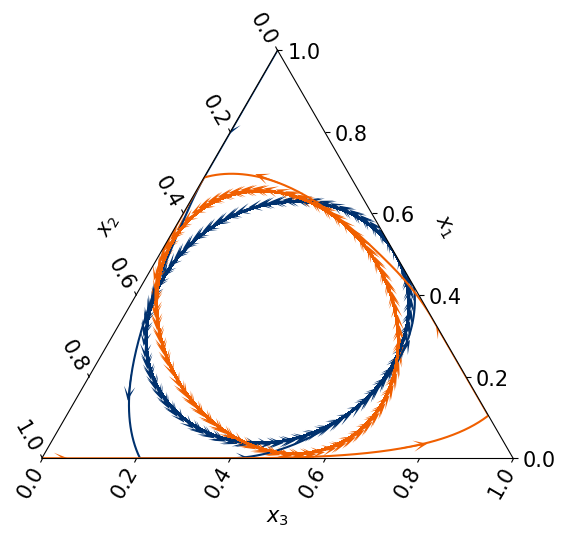

In [26]:
# Plot the two trajectories on a ternary plot

fig = plt.figure(figsize=(6, 6))
plt.rcParams.update({'font.size': 20})
# plt.subplots_adjust(wspace=-0.6, hspace=-1)

plt.rcParams.update({'font.size': 15})
ax = fig.add_subplot(projection='ternary')

ax.plot(trajectory_x_1, trajectory_x_2, trajectory_x_3, label='x', c='#00316E')
ax.plot(trajectory_y_1, trajectory_y_2, trajectory_y_3, label='y', c='#F05F00')

a = 0.05
for k in range(10000):
    if k % 80 == 0:
        ax.quiver(trajectory_x_1[k], trajectory_x_2[k], trajectory_x_3[k], a * (trajectory_x_1[k + 1] - trajectory_x_1[k]), a * (trajectory_x_2[k + 1] - trajectory_x_2[k]), a * (trajectory_x_3[k + 1] - trajectory_x_3[k]), color='#00316E', width=0.003, headwidth=8, headlength=10)
for k in range(10000):
    if k % 80 == 0:
        ax.quiver(trajectory_y_1[k], trajectory_y_2[k], trajectory_y_3[k], a * (trajectory_y_1[k + 1] - trajectory_y_1[k]), a * (trajectory_y_2[k + 1] - trajectory_y_2[k]), a * (trajectory_y_3[k + 1] - trajectory_y_3[k]), color='#F05F00', width=0.003, headwidth=8, headlength=10)

ax.set_tlabel(r'$x_1$')
ax.set_llabel(r'$x_2$')
ax.set_rlabel(r'$x_3$')

position = 'tick1'
ax.taxis.set_ticks_position(position)
ax.laxis.set_ticks_position(position)
ax.raxis.set_ticks_position(position)

ax.taxis.set_label_position(position)
ax.laxis.set_label_position(position)
ax.raxis.set_label_position(position)
plt.rcParams.update({'font.size': 18})

# The title for the whole plot
plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('interior_nash_eq_trajectory_ternary_plot.png', dpi=300)

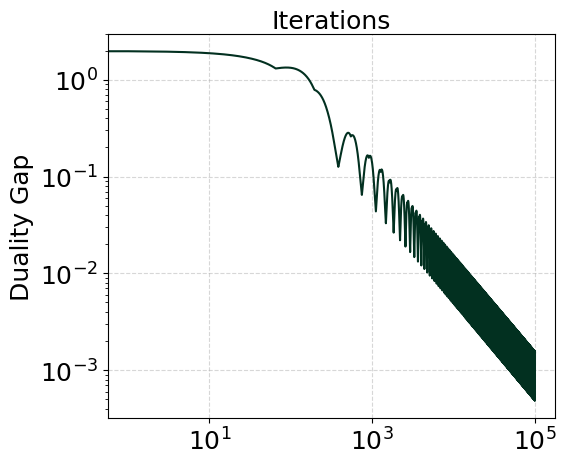

In [27]:
# duality gap

ax = plt.figure(figsize=(6, 5)).gca()

ax.loglog(k_array, val_duality_gap, c='#023020')
ax.set_xlabel('Iterations')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Duality Gap')
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Save the plot
ax.figure.savefig('interior_nash_eq_duality_gap.png', dpi=300)

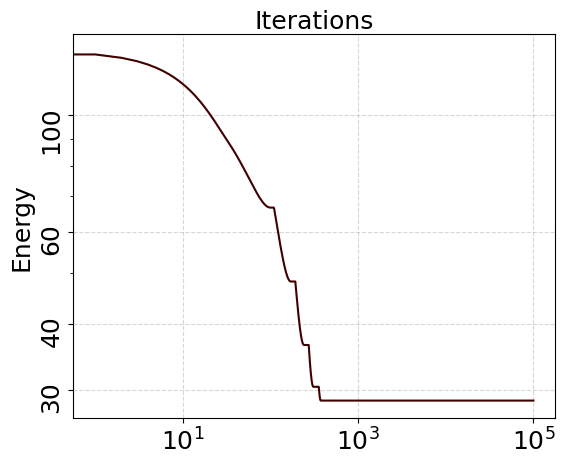

In [28]:
# energy function

ax = plt.figure(figsize=(6, 5)).gca()

ax.loglog(k_array, energy_list, c='#400000')
ax.set_xlabel('Iterations')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Energy')
ylabels = yticks = [30, 40, 60, 100]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, rotation=90)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()
# Save the plot
ax.figure.savefig('interior_nash_eq_energy.png', dpi=300)

# With interior NE - Example 2 (Complex Cycling)

# Without interior NE

In [29]:
np.random.seed(1)
A = np.random.normal(0, 1, (3, 3))

print(A)

# find x_star and y_star using PDHG

n = A.shape[0]

x0 = np.ones(n) / n
y0 = np.ones(n) / n

x = x0
y = y0
y_ = y0

eta = 0.01

for _ in range(1000000):
    x = projection_simplex_sort(x - eta * A @ (2 * y - y_))
    y_ = y
    y = projection_simplex_sort(y + eta * A.T @ x)

    if duality_gap(A, x, y) < 1e-10:
        print("Found good point!")
        break

x_star = x
y_star = y

print(x_star)
print(y_star)

[[ 1.62434536 -0.61175641 -0.52817175]
 [-1.07296862  0.86540763 -2.3015387 ]
 [ 1.74481176 -0.7612069   0.3190391 ]]
Found good point!
[0.         0.56386048 0.43613952]
[0.36599235 0.63400765 0.        ]


In [30]:
from tqdm import tqdm

x0 = np.array([1/3, 1/3, 1/3])
y0 = np.array([1/3, 1/3, 1/3])

x = x0
y = y0

eta = 0.01

trajectory_x_1 = [x[0]]
trajectory_x_2 = [x[1]]
trajectory_x_3 = [x[2]]
trajectory_y_1 = [y[0]]
trajectory_y_2 = [y[1]]
trajectory_y_3 = [y[2]]

avg_x = x
avg_y = y
k_array = []
val_duality_gap = []
energy_list = []
val_duality_gap_lst_iterate = []

for k in tqdm(range(100000)):
    x_ = x
    y_ = y
    x = projection_simplex_sort(x - eta * A @ y)
    y = projection_simplex_sort(y + eta * A.T @ x)  # Alternating

    avg_x = avg_x + (x - avg_x) / (k + 1)
    avg_y = avg_y + (y - avg_y) / (k + 1)


    if k >= 0:

        k_array.append(k)
        val_duality_gap.append(duality_gap(A, avg_x, avg_y))
        val_duality_gap_lst_iterate.append(duality_gap(A, x, y))
        energy_list.append(energy(x, y, x_star, y_star, A, eta, eta))

        if k % 100 == 0:
            pass

        trajectory_x_1.append(x[0])
        trajectory_x_2.append(x[1])
        trajectory_x_3.append(x[2])
        trajectory_y_1.append(y[0])
        trajectory_y_2.append(y[1])
        trajectory_y_3.append(y[2])

100%|██████████| 100000/100000 [00:06<00:00, 15579.31it/s]


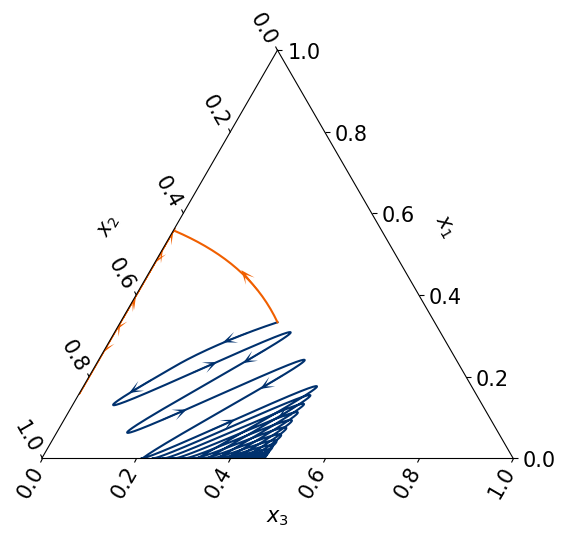

In [31]:
# Plot the two trajectories on a ternary plot

fig = plt.figure(figsize=(6, 6))
plt.rcParams.update({'font.size': 20})
# plt.subplots_adjust(wspace=-0.6, hspace=-1)

plt.rcParams.update({'font.size': 15})
ax = fig.add_subplot(projection='ternary')

ax.plot(trajectory_x_1, trajectory_x_2, trajectory_x_3, label='x', c='#00316E')
ax.plot(trajectory_y_1, trajectory_y_2, trajectory_y_3, label='y', c='#F05F00')

x_arrow_list = [10, 50, 150, 250, 380, 500, 650, 1000, ]
y_arrow_list = [10, 50, 100, 200, 500, 1000, 2000, 5000, 8000]

a = 0.05
for k in range(10000):
    if k in x_arrow_list:
        ax.quiver(trajectory_x_1[k], trajectory_x_2[k], trajectory_x_3[k], a * (trajectory_x_1[k + 1] - trajectory_x_1[k]), a * (trajectory_x_2[k + 1] - trajectory_x_2[k]), a * (trajectory_x_3[k + 1] - trajectory_x_3[k]), color='#00316E', width=0.003, headwidth=8, headlength=10)
for k in range(10000):
    if k in y_arrow_list:
        ax.quiver(trajectory_y_1[k], trajectory_y_2[k], trajectory_y_3[k], a * (trajectory_y_1[k + 1] - trajectory_y_1[k]), a * (trajectory_y_2[k + 1] - trajectory_y_2[k]), a * (trajectory_y_3[k + 1] - trajectory_y_3[k]), color='#F05F00', width=0.003, headwidth=8, headlength=10)

ax.set_tlabel(r'$x_1$')
ax.set_llabel(r'$x_2$')
ax.set_rlabel(r'$x_3$')

position = 'tick1'
ax.taxis.set_ticks_position(position)
ax.laxis.set_ticks_position(position)
ax.raxis.set_ticks_position(position)

ax.taxis.set_label_position(position)
ax.laxis.set_label_position(position)
ax.raxis.set_label_position(position)
plt.rcParams.update({'font.size': 18})

# The title for the whole plot
plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('no_interior_NE_trajectory_ternary_plot.png', dpi=300)

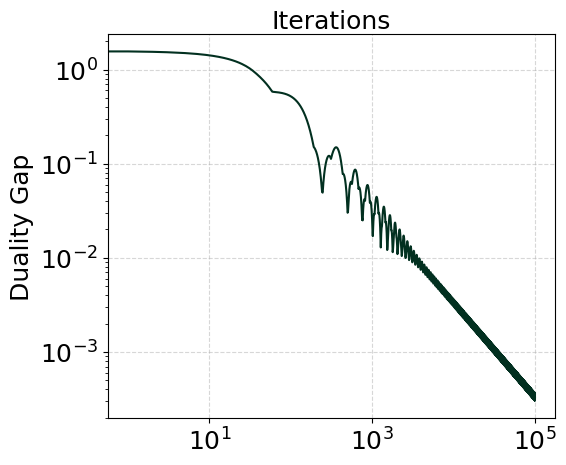

In [32]:
# duality gap

ax = plt.figure(figsize=(6, 5)).gca()

ax.loglog(k_array, val_duality_gap, c='#023020')
ax.set_xlabel('Iterations')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Duality Gap')
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Save the plot
ax.figure.savefig('no_interior_NE_duality_gap.png', dpi=300)

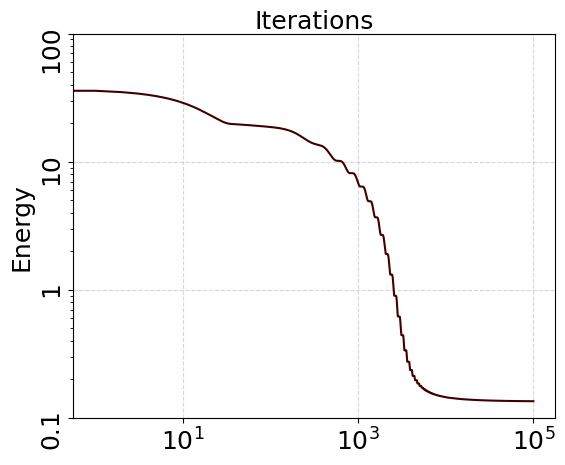

In [33]:
# energy function

ax = plt.figure(figsize=(6, 5)).gca()

ax.loglog(k_array, energy_list, c='#400000')
ax.set_xlabel('Iterations')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Energy')
ylabels = yticks = [0.1, 1, 10, 100]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, rotation=90)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Save the plot
ax.figure.savefig('no_interior_NE_energy.png', dpi=300)